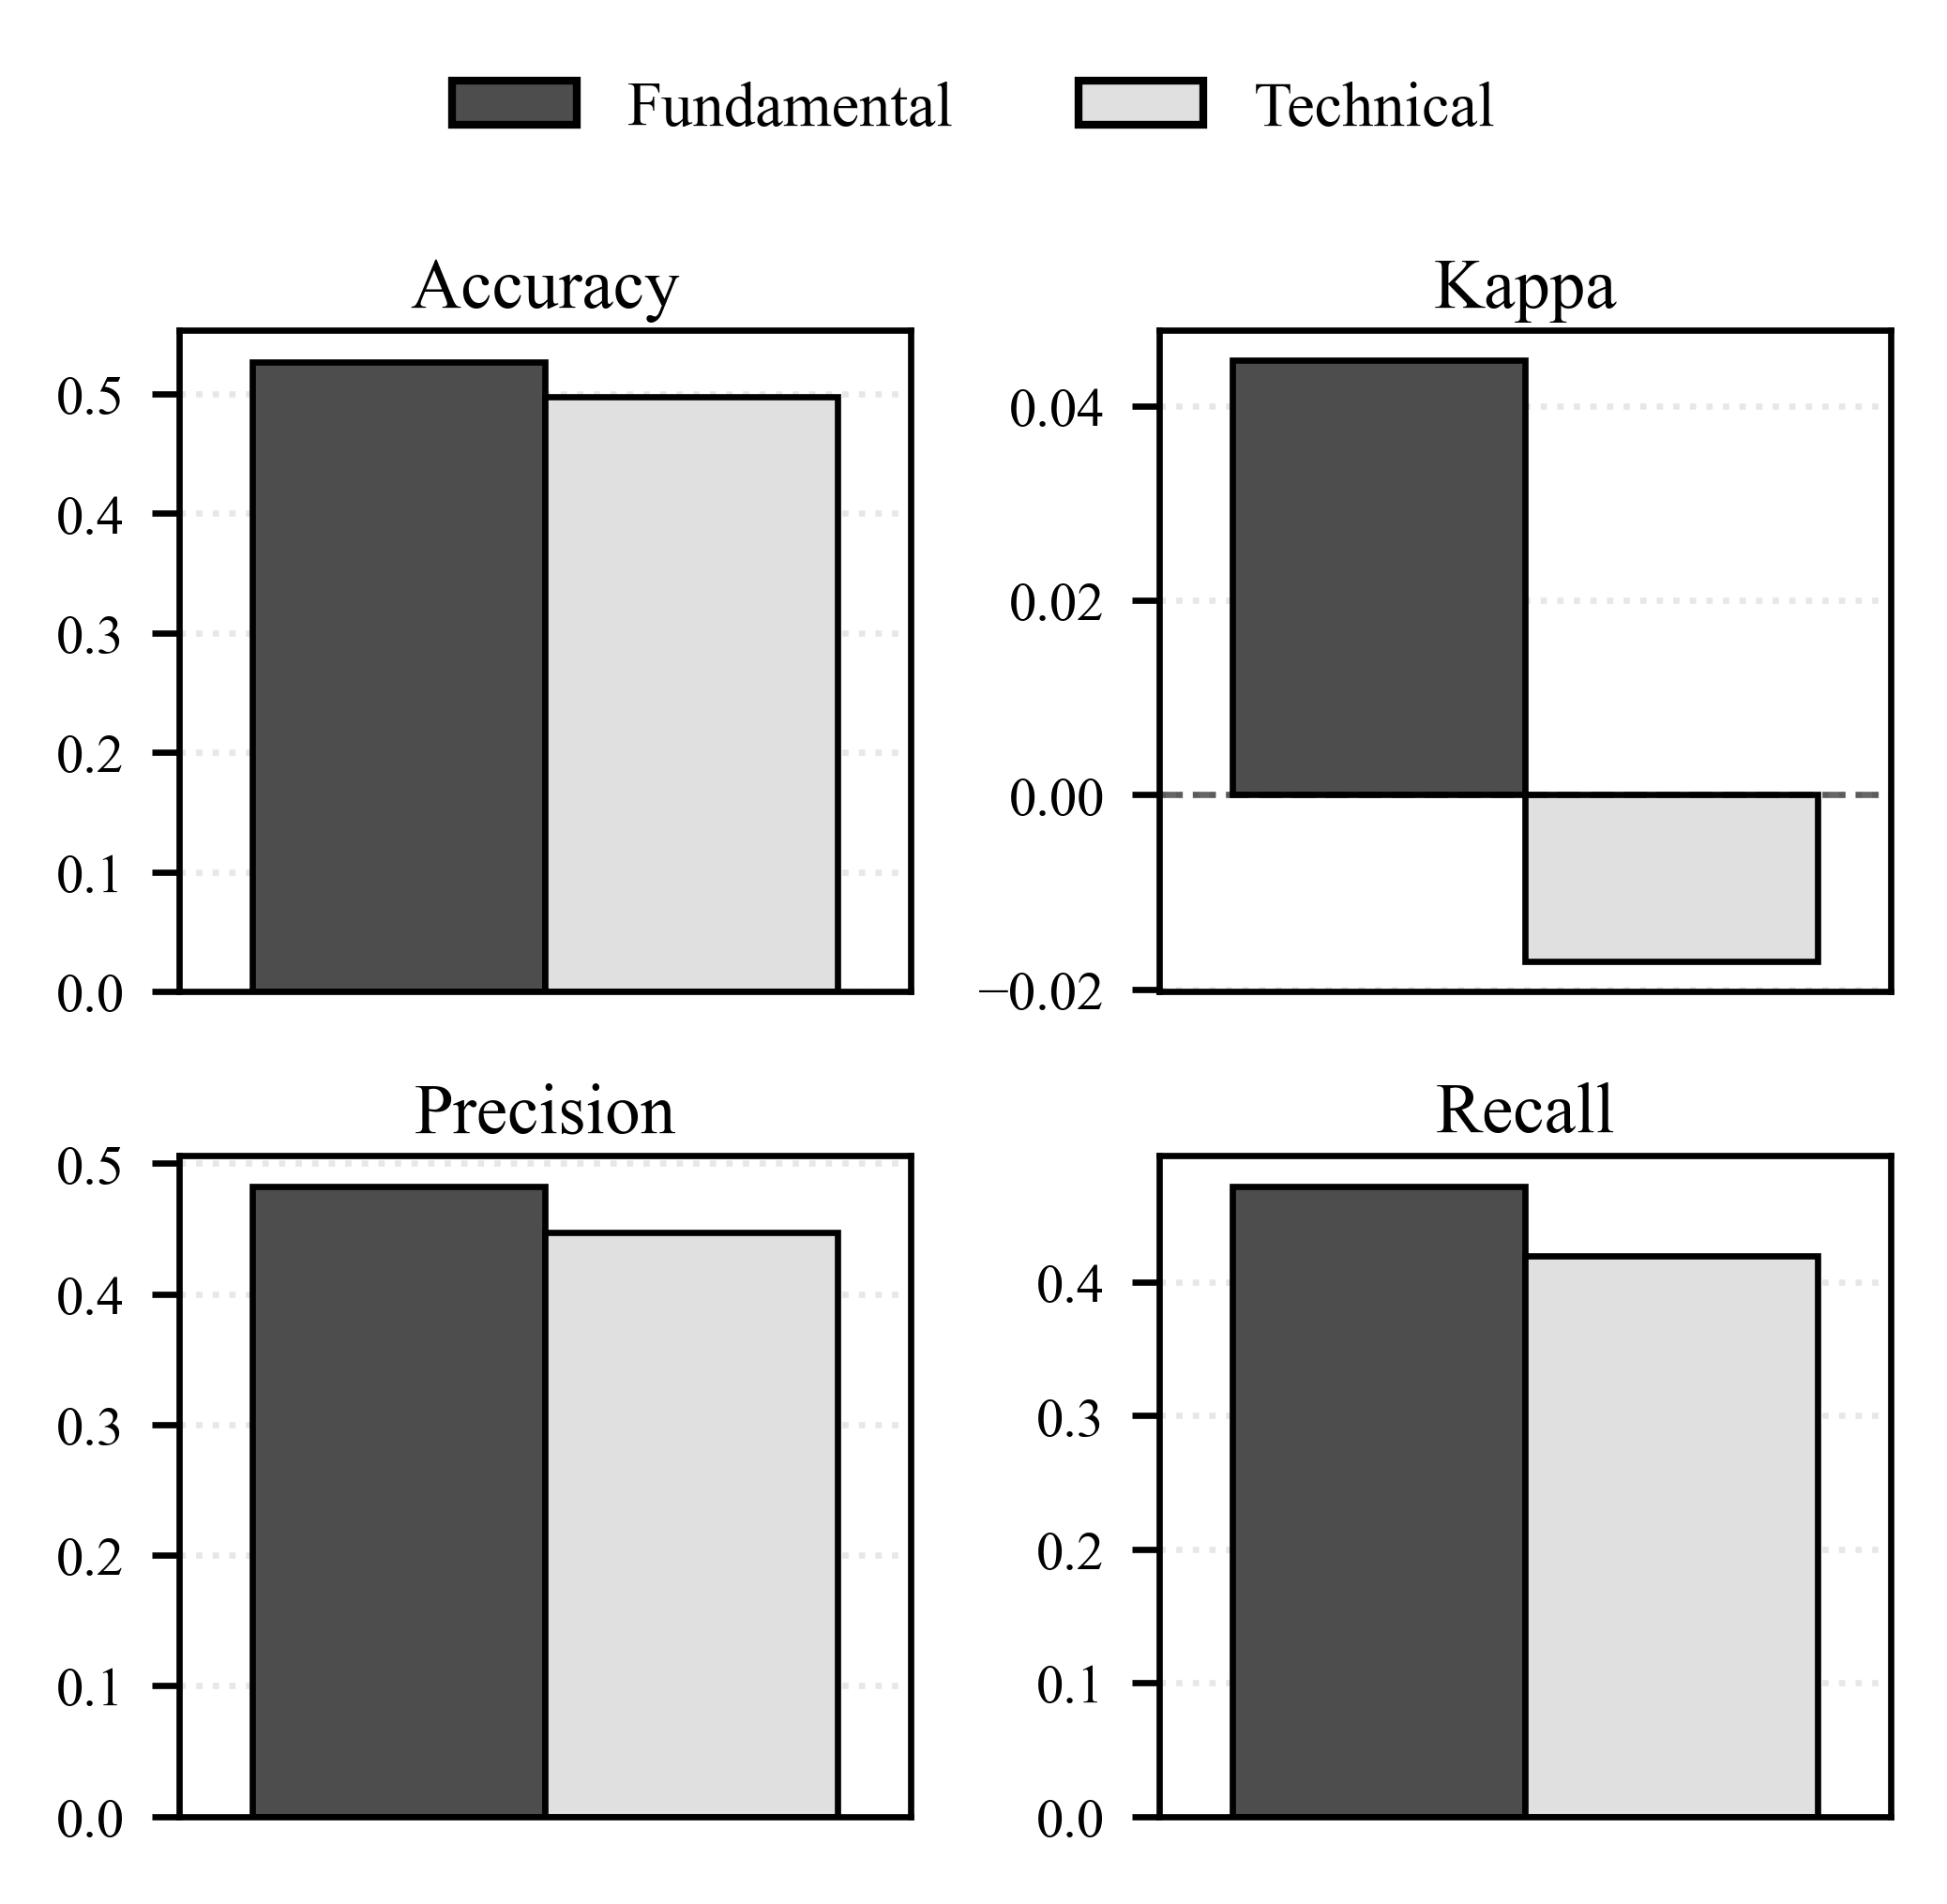

[INFO] Plot saved to: figures/high_liquidity_micro_lag150.pdf

HIGH-LIQUIDITY ASSET ANALYSIS (TOP 10 DIVERSIFIED) - Window Size (Lag)=150
      Domain Accuracy   Kappa Precision Recall
 Fundamental   0.5266  0.0447    0.4821 0.4714
   Technical   0.4976 -0.0172    0.4474 0.4199
------------------------------------------------------------


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# ==============================================================================
# 1. FORCE FONT LOADING (TIMES NEW ROMAN)
# ==============================================================================
possible_paths = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

font_path = None
for p in possible_paths:
    if os.path.exists(p):
        font_path = p
        break

try:
    if font_path:
        fm.fontManager.addfont(font_path)
        font_prop = fm.FontProperties(fname=font_path)
        exact_font_name = font_prop.get_name()
    else:
        exact_font_name = 'serif'
except Exception:
    exact_font_name = 'serif'

# ==============================================================================
# 2. IEEE CONFIGURATIONS (SINGLE COLUMN) - FLATTENED
# ==============================================================================
IEEE_COL_WIDTH = 3.5 
IEEE_HEIGHT = 3.2 

plt.rcParams.update({
    'font.family': exact_font_name,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

palette_map = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'}

# ==============================================================================
# 3. DATA AND MICRO-AVERAGE CALCULATION
# ==============================================================================
file_path = 'results/results_ARF_delay_1.csv' 
target_lag = 150

top_10_diversified = [
    'VALE3',  # Mining (Basic Materials)
    'PETR4',  # Oil, Gas and Biofuels
    'ITUB4',  # Banks (Financial)
    'RENT3',  # Car Rental (Cyclical Consumer)
    'ELET3',  # Electric Energy (Public Utility)
    'LREN3',  # Retail (Cyclical Consumer)
    'GGBR4',  # Steelmaking (Basic Materials)
    'HYPE3',  # Pharmacies and Drugstores (Health)
    'BRFS3',  # Processed Foods (Non-Cyclical Consumer)
    'CIEL3',  # Financial Services (Financial)
]

domain_map = {'fund': 'Fundamental', 'nao_fund': 'Technical'}

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    if 'fh' in df.columns: df.rename(columns={'fh': 'lag'}, inplace=True)
    if 'base' in df.columns: df.rename(columns={'base': 'dataset'}, inplace=True)
    if 'categoria' in df.columns: df.rename(columns={'categoria': 'category'}, inplace=True)
    
    df_filtered = df[df['lag'] == target_lag].copy()
    df_target = df_filtered[df_filtered['dataset'].isin(top_10_diversified)].copy()
    df_target['Domain'] = df_target['category'].map(domain_map)
    
    # Micro-Average Calculation
    df_micro = df_target.groupby('Domain')[['TP', 'TN', 'FP', 'FN']].sum().reset_index()
    
    total = df_micro['TP'] + df_micro['TN'] + df_micro['FP'] + df_micro['FN']
    
    df_micro['Accuracy'] = (df_micro['TP'] + df_micro['TN']) / total
    df_micro['Precision'] = df_micro['TP'] / (df_micro['TP'] + df_micro['FP'])
    df_micro['Recall'] = df_micro['TP'] / (df_micro['TP'] + df_micro['FN'])
    
    po = df_micro['Accuracy']
    pe_pos = ((df_micro['TP'] + df_micro['FP']) * (df_micro['TP'] + df_micro['FN'])) / (total**2)
    pe_neg = ((df_micro['TN'] + df_micro['FN']) * (df_micro['TN'] + df_micro['FP'])) / (total**2)
    pe = pe_pos + pe_neg
    df_micro['Kappa'] = (po - pe) / (1 - pe)

else:
    print(f"[WARNING] File not found: {file_path}. Using simulated data.")
    df_micro = pd.DataFrame({
        'Domain': ['Fundamental', 'Technical'],
        'Accuracy': [0.525, 0.495],
        'Kappa': [0.051, -0.02],
        'Precision': [0.51, 0.49],
        'Recall': [0.52, 0.55]
    })

df_melted = df_micro.melt(id_vars='Domain', 
                          value_vars=['Accuracy', 'Kappa', 'Precision', 'Recall'], 
                          var_name='Metric', value_name='Score')

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
metrics_order = ['Accuracy', 'Kappa', 'Precision', 'Recall']

fig, axes = plt.subplots(2, 2, figsize=(IEEE_COL_WIDTH, IEEE_HEIGHT)) 
axes = axes.flatten()

for i, metric in enumerate(metrics_order):
    ax = axes[i]
    subset = df_melted[df_melted['Metric'] == metric]
    
    sns.barplot(
        data=subset, x='Metric', y='Score', hue='Domain',
        palette=palette_map,
        edgecolor='black', linewidth=0.8, 
        ax=ax
    )
    
    ax.set_title(metric, fontweight='normal', pad=3)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]) 
    ax.set_axisbelow(True)
    
    if metric == 'Kappa':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

    if ax.get_legend():
        ax.get_legend().remove()

# Manual Legend
handles = [Patch(facecolor=palette_map['Fundamental'], edgecolor='black', label='Fundamental'),
           Patch(facecolor=palette_map['Technical'], edgecolor='black', label='Technical')]

fig.legend(handles, ['Fundamental', 'Technical'], 
           loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=2, frameon=False, fontsize=8)

plt.tight_layout()
plt.subplots_adjust(top=0.88) 

os.makedirs('figures', exist_ok=True)

output_filename = f'figures/high_liquidity_micro_lag{target_lag}.pdf'
plt.savefig(output_filename, format='pdf', dpi=600, bbox_inches='tight') 
plt.show()

print(f"[INFO] Plot saved to: {output_filename}")

# ==============================================================================
# 5. PRINT VALUES
# ==============================================================================
print("\n" + "="*60)
print(f"HIGH-LIQUIDITY ASSET ANALYSIS (TOP 10 DIVERSIFIED) - Window Size (Lag)={target_lag}")
print("="*60)

col_order = ['Domain', 'Accuracy', 'Kappa', 'Precision', 'Recall']

formatters = {
    'Accuracy': '{:.4f}'.format,
    'Kappa': '{:.4f}'.format,
    'Precision': '{:.4f}'.format,
    'Recall': '{:.4f}'.format
}

print(df_micro[col_order].to_string(index=False, formatters=formatters))
print("-" * 60)